
--- Training with 2 Neurons (Too Small) ---
Final Loss (2 Neurons): 0.0011

--- Training with 8 Neurons (Large Enough) ---
Final Loss (8 Neurons): 0.0008


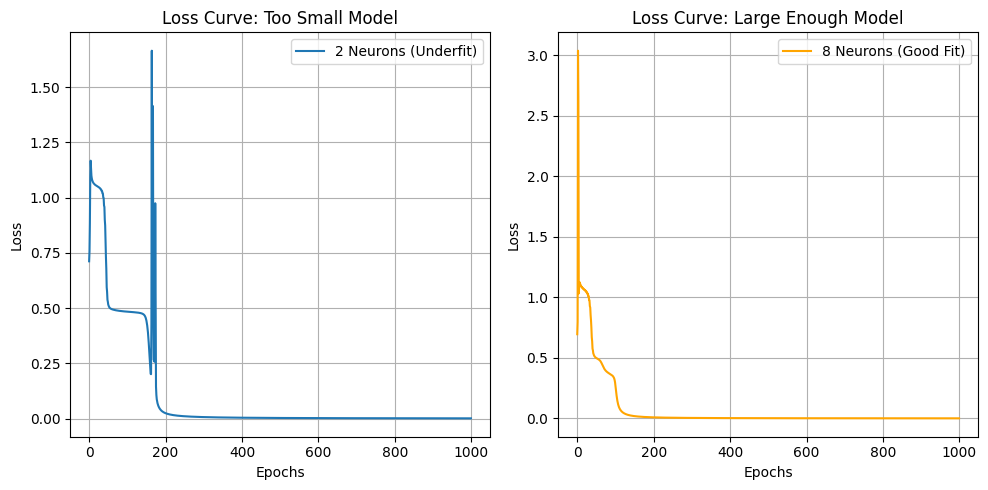

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Generation (XOR jaisa complex pattern banane ke liye)
# Hum 4 points le rahe hain jo linearly separable nahi hain
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]], requires_grad=False)
y = torch.tensor([[0.], [1.], [1.], [0.]], requires_grad=False) # XOR problem

# 2. Model Definition
class SimpleNN(nn.Module):
    def __init__(self, hidden_neurons):
        super(SimpleNN, self).__init__()
        # Input Layer -> Hidden Layer -> Output Layer
        self.layer1 = nn.Linear(2, hidden_neurons)
        self.activation = nn.Sigmoid() # Playground mein default sigmoid/tanh hota hai
        self.layer2 = nn.Linear(hidden_neurons, 1)
        self.output_act = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return self.output_act(x)

# 3. Training Function
def train_model(model, epochs=1000):
    optimizer = optim.SGD(model.parameters(), lr=10) # High learning rate like Playground
    criterion = nn.BCELoss()

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses, model

# --- Scenario A: Too Small (2 Neurons) - Underfitting ---
print("\n--- Training with 2 Neurons (Too Small) ---")
model_small = SimpleNN(hidden_neurons=2)
losses_small, _ = train_model(model_small)
print(f"Final Loss (2 Neurons): {losses_small[-1]:.4f}")

# --- Scenario B: Large Enough (8 Neurons) - Better Fit ---
print("\n--- Training with 8 Neurons (Large Enough) ---")
model_large = SimpleNN(hidden_neurons=8)
losses_large, _ = train_model(model_large)
print(f"Final Loss (8 Neurons): {losses_large[-1]:.4f}")

# 4. Visualization
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_small, label='2 Neurons (Underfit)')
plt.title('Loss Curve: Too Small Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(losses_large, label='8 Neurons (Good Fit)', color='orange')
plt.title('Loss Curve: Large Enough Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Data Preparation (MNIST Dataset)
# Images ko normalize kar rahe hain taaki training fast ho
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

if not train_loader:
  train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
  test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)



train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Model Banana (Multi-Layer Perceptron)
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        # Input: 28x28 image = 784 pixels
        self.layer1 = nn.Linear(784, 128)  # Hidden Layer 1
        self.relu = nn.ReLU()              # Activation Function (Non-linearity)
        self.layer2 = nn.Linear(128, 10)   # Output Layer (10 digits 0-9)

    def forward(self, x):
        x = x.view(-1, 784)  # Image ko flat vector mein badlo
        x = self.layer1(x)
        x = self.relu(x)     # Activation apply kiya
        x = self.layer2(x)
        return x

model = NeuralNet()

# 3. Loss Function aur Optimizer define karna
criterion = nn.CrossEntropyLoss()  # Classification ke liye
optimizer = optim.Adam(model.parameters(), lr=0.001) # Learning rate 0.001
print(model.parameters())
# 4. Training Loop (Ye heart of Deep Learning hai)
num_epochs = 1

for epoch in range(num_epochs):
    for images, labels in train_loader:
        print(images)
        print(labels)
        # Forward Pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward Pass & Optimization
        optimizer.zero_grad()  # Purana gradient clear karo
        loss.backward()        # Naya gradient calculate karo (Backpropagation)
        optimizer.step()       # Weights update karo

    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

print("Training Complete! 🎉")

Streaming output truncated to the last 5000 lines.

        [[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]])
tensor([4, 7, 0, 1, 0, 5, 4, 5, 7, 0, 0, 4, 9, 5, 6, 6, 9, 7, 6, 0, 0, 5, 8, 9,
        4, 4, 5, 1, 2, 4, 3, 7, 1, 8, 9, 3, 3, 6, 9, 8, 3, 3, 1, 4, 4, 4, 0, 1,
        1, 0, 8, 5, 5, 4, 1, 3, 4, 9, 6, 6, 3, 0, 2, 3])
tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]],


        [[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -

In [ ]:
# Save karna
torch.save(model.state_dict(), 'mnist_model.pth')

# Load karna (Inference ke liye)
model = NeuralNet()
model.load_state_dict(torch.load('mnist_model.pth'))
model.eval() # Evaluation mode on karna na bhulein

NeuralNet(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)